# Trabalho de Inteligência Artificial - CNN para GTSRB

### Experimento 3: Data Augmentation — Avaliando o impacto de técnicas de aumento de dados na acurácia

### 1. Setup

In [2]:
from genericpath import exists
#!/usr/bin/env python3
import os
import json
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader, random_split

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model_pth_path = '/content/models_pth'
if not os.path.exists(model_pth_path):
    os.mkdir(model_pth_path)

figs_path = '/content/figs'
if not os.path.exists(figs_path):
    os.mkdir(figs_path)

checkpoints_path = '/content/checkpoints'
if not os.path.exists(checkpoints_path):
    os.mkdir(checkpoints_path)

results_path = '/content/results'
if not os.path.exists(results_path):
    os.mkdir(results_path)


Using device: cuda


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/trabalho-ia-gtsrb-cnn')
from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions


Mounted at /content/drive


### 2. Funções para Cálculo e Comparação das Métricas

In [3]:
def train(trainloader, model, criterion, optimizer, device) -> tuple[float, float]:
    total_loss, correct, total = 0.0, 0, 0

    model.train()
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def validate(val_loader, model, criterion, device) -> tuple[float, float]:
    total_loss, correct, total = 0.0, 0, 0

    model.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

def get_confusion_matrix(loader, model, device, num_class=43) -> np.ndarray:
    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            for t, p in zip(labels.cpu().numpy(), predicted.cpu().numpy()):
                cm[t, p] += 1
    return cm

def per_class_accuracy(ytrue, ypred) -> np.ndarray:
    acc = np.zeros(NUM_CLASSES)
    for c in range(NUM_CLASSES):
        mask = ytrue == c
        if mask.sum() > 0:
            acc[c] = (ypred[mask] == ytrue[mask]).mean()
    return acc

### Funções de salvamento e carregamento de modelos

In [4]:
def save_model(model, file_name, path=f'{model_pth_path}'):
    PATH = f'{path}/{file_name}'
    torch.save(model.state_dict(), PATH)
    return PATH

def load_model(file_name, path=f'{model_pth_path}'):
    PATH = f'{path}/{file_name}'
    model = EHMNet()
    model.load_state_dict(torch.load(PATH))
    return model

### 3. Criando Classe para Rede Neural

In [5]:
# Classe do Modelo
class EHMNet(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super(EHMNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        spatial = img_size // 4
        flatten_size = 64 * spatial * spatial
        self.fc1 = nn.Linear(in_features=flatten_size, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

### 4. Hiperparâmetros e Carregamento dos Dados

In [6]:
# Hiperparâmetros
IMG_SIZE   = 32
BATCH_SIZE = 128
NUM_EPOCHS = 40
LR         = 0.001

# val_loader e test_loader vêm do arquivo auxiliar (sem augmentation)
_, val_loader, test_loader = get_dataloaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

100%|██████████| 187M/187M [00:16<00:00, 11.3MB/s]
100%|██████████| 89.0M/89.0M [00:06<00:00, 13.5MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 293kB/s]


### 5. Definindo os Transforms de Data Augmentation

In [7]:
# Normalização padrão (mesma do arquivo auxiliar)
MEAN = (0.3403, 0.3121, 0.3214)
STD  = (0.2724, 0.2608, 0.2669)

# Transform SEM augmentation — referência
transform_base = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

# Transform COM augmentation — aplicado apenas no treino
# Técnica 1: RandomRotation — simula placas vistas em ângulos diferentes
# Técnica 2: ColorJitter    — simula variações de iluminação e condições climáticas
# Técnica 3: RandomAffine  — simula pequenos deslocamentos da placa no frame
# Técnica 4: GaussianBlur  — simula câmeras de menor qualidade ou movimento
transform_aug = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.4, contrast=0.4),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.5),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

print('Transforms definidos.')

Transforms definidos.


In [8]:
# Wrapper para aplicar transform diferente em cada subset
class TransformDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset    = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        img, label = self.subset[idx]
        return self.transform(img), label


# Mesmo split do arquivo auxiliar: seed=42, 80% treino / 20% validação
full_train_dataset = torchvision.datasets.GTSRB(root='./data', split='train', download=True)
n_total = len(full_train_dataset)
n_train = int(0.8 * n_total)
n_val   = n_total - n_train

generator = torch.Generator().manual_seed(42)
train_subset, _ = random_split(full_train_dataset, [n_train, n_val], generator=generator)

# train_loader SEM augmentation (referência)
train_loader_base = DataLoader(
    TransformDataset(train_subset, transform_base),
    batch_size=BATCH_SIZE, shuffle=True
)

# train_loader COM augmentation
train_loader_aug = DataLoader(
    TransformDataset(train_subset, transform_aug),
    batch_size=BATCH_SIZE, shuffle=True
)

print(f'train_loader_base : {len(train_loader_base)} batches')
print(f'train_loader_aug  : {len(train_loader_aug)} batches')
print(f'val_loader        : {len(val_loader)} batches')
print(f'test_loader       : {len(test_loader)} batches')

train_loader_base : 167 batches
train_loader_aug  : 167 batches
val_loader        : 42 batches
test_loader       : 99 batches


### 6. Visualizando o Efeito do Augmentation

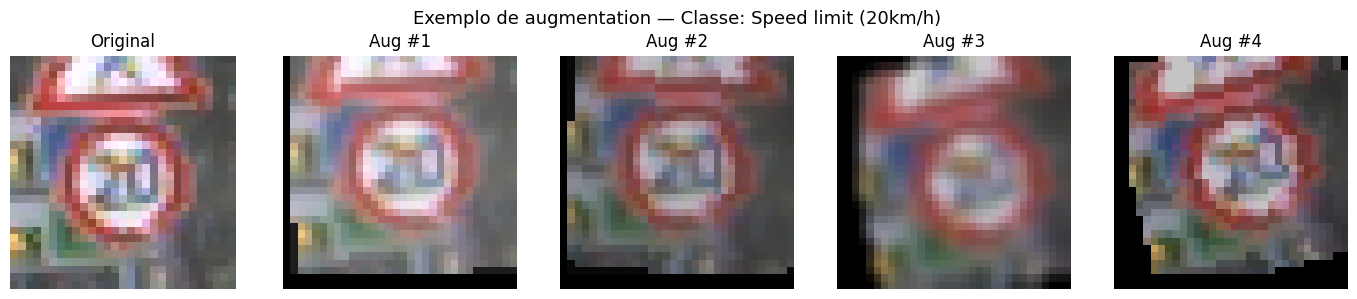

In [9]:
sample_img, sample_label = full_train_dataset[0]

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
fig.suptitle(f'Exemplo de augmentation — Classe: {GTSRB_CLASSES[sample_label]}', fontsize=13)

axes[0].imshow(sample_img)
axes[0].set_title('Original')
axes[0].axis('off')

aug_preview = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.4, contrast=0.4),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.5),
])

for i in range(1, 5):
    axes[i].imshow(aug_preview(sample_img))
    axes[i].set_title(f'Aug #{i}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('/content/figs/exp3_aug_preview.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. Função de Treino para Experimento

In [11]:
def run_experiment(name, train_loader, device, num_epochs=NUM_EPOCHS):
    model     = EHMNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR)

    best_val_acc = 0.0
    best_model   = None
    best_epoch   = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f'Experimento: {name}\n')

    for epoch in range(num_epochs):
        train_loss, train_acc = train(train_loader, model, criterion, optimizer, device)
        val_loss, val_acc     = validate(val_loader, model, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch   = epoch + 1
            best_model   = model

        print(f'Epoch {(epoch+1):02d}/{num_epochs} - Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}')

    print(f'\nMelhor acurácia de validação: {best_val_acc:.4f} (epoch {best_epoch})')
    checkpoint_path = save_model(best_model, f'{name}_best_model.pth')

    return {
        'name': name,
        'model': best_model,
        'history': history,
        'checkpoint_path': checkpoint_path,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch
    }

### 8. Experimento 3.1 - Sem Augmentation (referência)

In [12]:
result_base = run_experiment('sem_aug', train_loader_base, device)

Experimento: sem_aug

Epoch 01/40 - Train Loss: 1.4362 - Train Acc: 0.6076 - Val Loss: 0.3589 - Val Acc: 0.9045
Epoch 02/40 - Train Loss: 0.2341 - Train Acc: 0.9361 - Val Loss: 0.1035 - Val Acc: 0.9814
Epoch 03/40 - Train Loss: 0.1001 - Train Acc: 0.9727 - Val Loss: 0.0642 - Val Acc: 0.9854
Epoch 04/40 - Train Loss: 0.0586 - Train Acc: 0.9848 - Val Loss: 0.0353 - Val Acc: 0.9923
Epoch 05/40 - Train Loss: 0.0313 - Train Acc: 0.9925 - Val Loss: 0.1116 - Val Acc: 0.9773
Epoch 06/40 - Train Loss: 0.0250 - Train Acc: 0.9943 - Val Loss: 0.0206 - Val Acc: 0.9949
Epoch 07/40 - Train Loss: 0.0137 - Train Acc: 0.9970 - Val Loss: 0.0167 - Val Acc: 0.9957
Epoch 08/40 - Train Loss: 0.0113 - Train Acc: 0.9973 - Val Loss: 0.0220 - Val Acc: 0.9934
Epoch 09/40 - Train Loss: 0.0239 - Train Acc: 0.9932 - Val Loss: 0.0246 - Val Acc: 0.9925
Epoch 10/40 - Train Loss: 0.0159 - Train Acc: 0.9959 - Val Loss: 0.0150 - Val Acc: 0.9961
Epoch 11/40 - Train Loss: 0.0093 - Train Acc: 0.9976 - Val Loss: 0.0106 - Val 

### 9. Experimento 3.2 - Com Augmentation

In [13]:
result_aug = run_experiment('com_aug', train_loader_aug, device)

Experimento: com_aug

Epoch 01/40 - Train Loss: 2.3498 - Train Acc: 0.3304 - Val Loss: 1.1920 - Val Acc: 0.6207
Epoch 02/40 - Train Loss: 1.2308 - Train Acc: 0.6194 - Val Loss: 0.5598 - Val Acc: 0.8194
Epoch 03/40 - Train Loss: 0.7895 - Train Acc: 0.7580 - Val Loss: 0.3018 - Val Acc: 0.9215
Epoch 04/40 - Train Loss: 0.5729 - Train Acc: 0.8205 - Val Loss: 0.1801 - Val Acc: 0.9476
Epoch 05/40 - Train Loss: 0.4524 - Train Acc: 0.8600 - Val Loss: 0.1179 - Val Acc: 0.9724
Epoch 06/40 - Train Loss: 0.3833 - Train Acc: 0.8825 - Val Loss: 0.0963 - Val Acc: 0.9743
Epoch 07/40 - Train Loss: 0.3068 - Train Acc: 0.9070 - Val Loss: 0.0669 - Val Acc: 0.9842
Epoch 08/40 - Train Loss: 0.2657 - Train Acc: 0.9219 - Val Loss: 0.0485 - Val Acc: 0.9889
Epoch 09/40 - Train Loss: 0.2336 - Train Acc: 0.9306 - Val Loss: 0.0404 - Val Acc: 0.9910
Epoch 10/40 - Train Loss: 0.2171 - Train Acc: 0.9347 - Val Loss: 0.0344 - Val Acc: 0.9925
Epoch 11/40 - Train Loss: 0.1891 - Train Acc: 0.9429 - Val Loss: 0.0346 - Val 

In [14]:
all_results = {
    'sem_aug': result_base,
    'com_aug': result_aug
}
# Salva resumo em checkpoints/ (padrão do grupo)
to_save = {
    name: {
        'best_val_acc': r['best_val_acc'],
        'best_epoch':   r['best_epoch'],
        'history': {k: [float(x) for x in v] for k, v in r['history'].items()}
    }
    for name, r in all_results.items()
}
with open('/content/checkpoints/exp3_summary.json', 'w') as f:
    json.dump(to_save, f, indent=2)
print('Resumo salvo em checkpoints/exp3_summary.json')


Resumo salvo em checkpoints/exp3_summary.json


### 10. Comparando Curvas de Treino

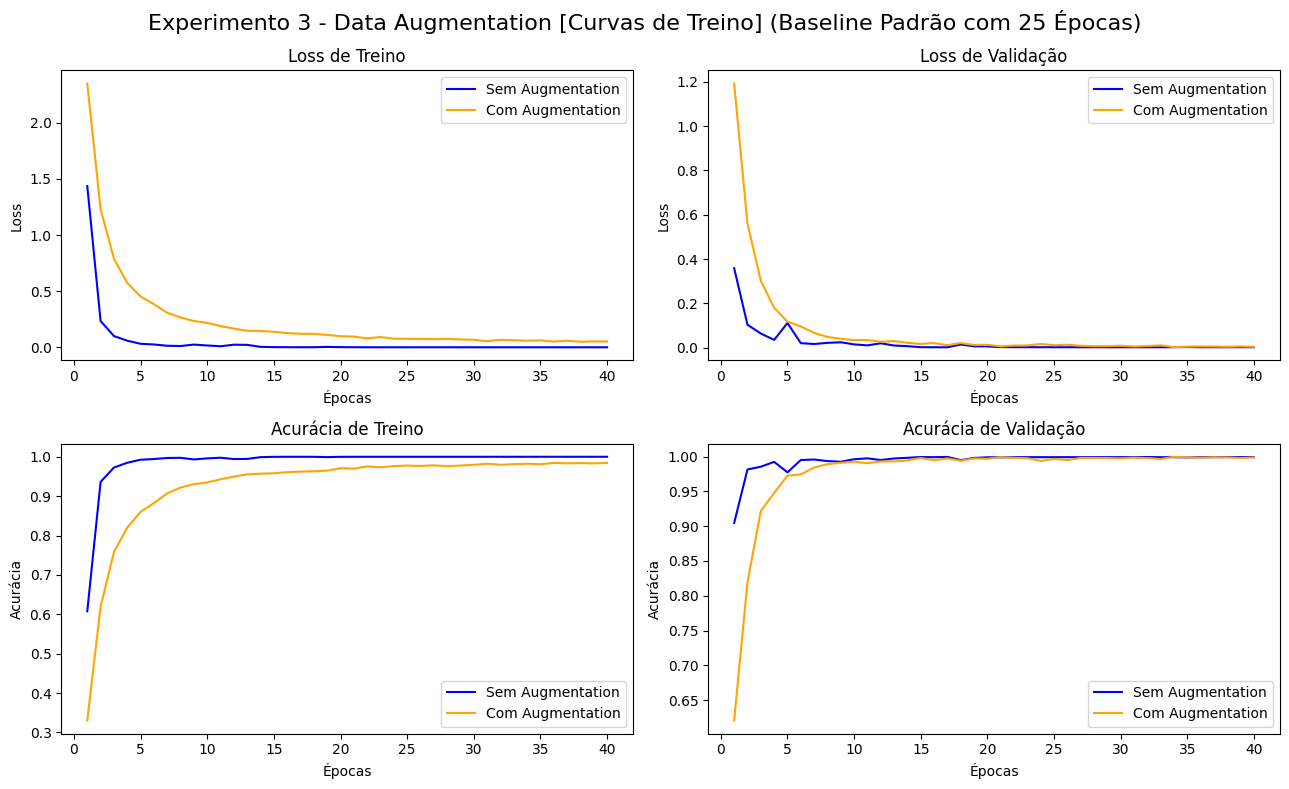

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
epochs = range(1, NUM_EPOCHS + 1)
colors = {'sem_aug': 'blue', 'com_aug': 'orange'}
labels = {'sem_aug': 'Sem Augmentation', 'com_aug': 'Com Augmentation'}

for name, r in all_results.items():
    axes[0, 0].plot(epochs, r['history']['train_loss'], label=labels[name], color=colors[name])
    axes[0, 0].set_title('Loss de Treino')
    axes[0, 0].set_xlabel('Épocas')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()

for name, r in all_results.items():
    axes[0, 1].plot(epochs, r['history']['val_loss'], label=labels[name], color=colors[name])
    axes[0, 1].set_title('Loss de Validação')
    axes[0, 1].set_xlabel('Épocas')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()

for name, r in all_results.items():
    axes[1, 0].plot(epochs, r['history']['train_acc'], label=labels[name], color=colors[name])
    axes[1, 0].set_title('Acurácia de Treino')
    axes[1, 0].set_xlabel('Épocas')
    axes[1, 0].set_ylabel('Acurácia')
    axes[1, 0].legend()

for name, r in all_results.items():
    axes[1, 1].plot(epochs, r['history']['val_acc'], label=labels[name], color=colors[name])
    axes[1, 1].set_title('Acurácia de Validação')
    axes[1, 1].set_xlabel('Épocas')
    axes[1, 1].set_ylabel('Acurácia')
    axes[1, 1].legend()

plt.suptitle('Experimento 3 - Data Augmentation [Curvas de Treino] (Baseline Padrão com 25 Épocas)', fontsize=16)
plt.tight_layout()
plt.savefig('/content/figs/exp3_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### 11. Avaliando Resultados no Conjunto de Teste

In [16]:
test_results = {}

for name, r in all_results.items():
    model = EHMNet().to(device)
    model.load_state_dict(torch.load(r['checkpoint_path']))
    model.eval()

    ytrue, ypred = [], []
    with torch.no_grad():
        for images, labels_batch in test_loader:
            images = images.to(device)
            pred   = model(images).argmax(1).cpu().numpy()
            ytrue.append(labels_batch.numpy())
            ypred.append(pred)

    ytrue = np.concatenate(ytrue)
    ypred = np.concatenate(ypred)
    pca   = per_class_accuracy(ytrue, ypred)
    global_acc = float((ypred == ytrue).mean())
    macro_acc  = float(pca.mean())

    test_results[name] = {
        'ytrue': ytrue,
        'ypred': ypred,
        'per_class_acc': pca,
        'global_acc': global_acc,
        'macro_acc': macro_acc,
        'model': model
    }

    print(f'{name:<10} — Global Acc: {global_acc:.4f} | Macro Acc: {macro_acc:.4f}')

sem_aug    — Global Acc: 0.9092 | Macro Acc: 0.8603
com_aug    — Global Acc: 0.9154 | Macro Acc: 0.8767


### 12. Comparando Matriz de Confusão

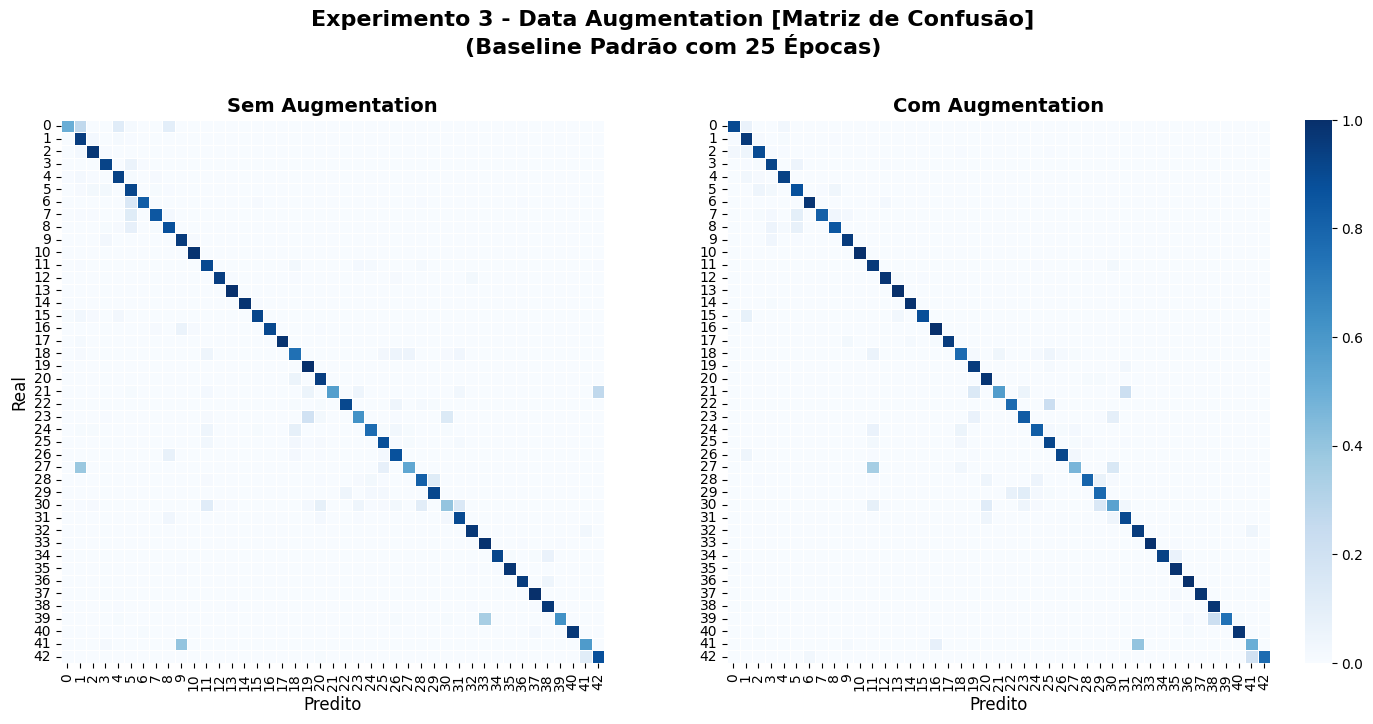

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
cm = {k: get_confusion_matrix(test_loader, r['model'], device) for k, r in test_results.items()}
labels = {'sem_aug': 'Sem Augmentation', 'com_aug': 'Com Augmentation'}

for i, (name, r) in enumerate(test_results.items()):
    cm_norm = cm[name].astype(float) / cm[name].sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm,
        annot=False,
        xticklabels=np.arange(NUM_CLASSES),
        yticklabels=np.arange(NUM_CLASSES),
        ax=axes[i],
        cmap='Blues',
        cbar=i == 1,
        vmin=0, vmax=1,
        linewidths=0.5,
        linecolor='white',
        square=True,
    )
    axes[i].set_title(f'{labels[name]}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Predito', fontsize=12)
    axes[i].set_ylabel('Real' if i == 0 else '', fontsize=12)
    axes[i].tick_params(labelsize=10)

plt.suptitle(
    'Experimento 3 - Data Augmentation [Matriz de Confusão]\n(Baseline Padrão com 25 Épocas)',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('/content/figs/exp3_cm.png', dpi=150, bbox_inches='tight')
plt.show()

### 13. Comparando Acurácia por Classe

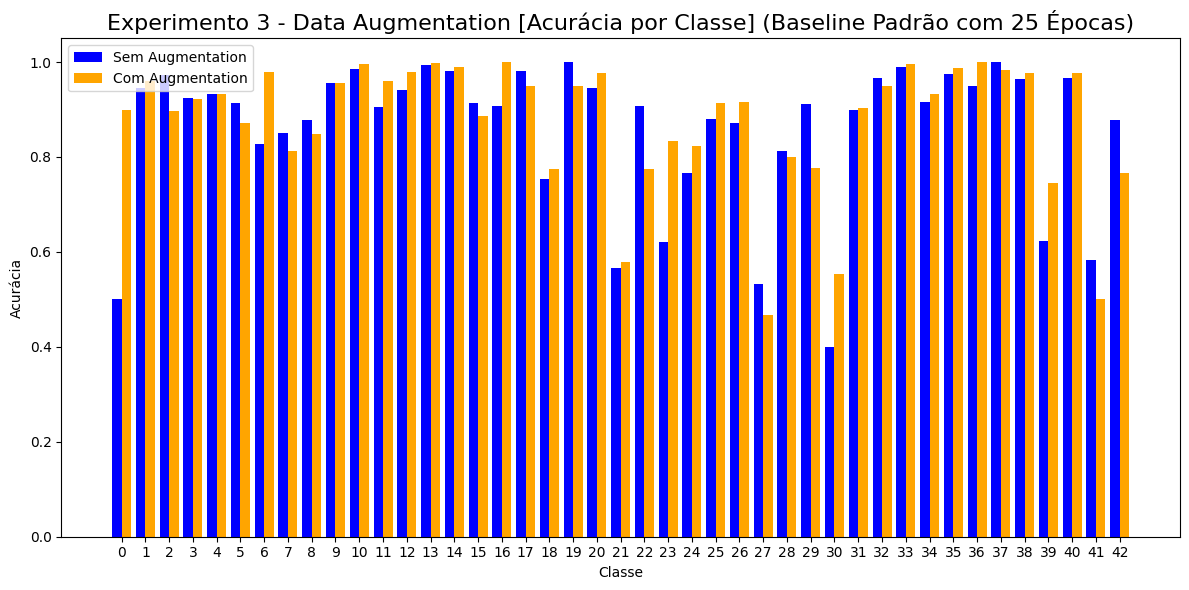


Top 5 classes que mais melhoraram com augmentation:
  Classe 00 (Speed limit (20km/h)): +0.4000
  Classe 23 (Slippery road): +0.2133
  Classe 06 (End of speed limit (80km/h)): +0.1533
  Classe 30 (Beware of ice/snow): +0.1533
  Classe 39 (Keep left): +0.1222

Top 5 classes que pioraram com augmentation:
  Classe 29 (Bicycles crossing): -0.1333
  Classe 22 (Bumpy road): -0.1333
  Classe 42 (End no passing veh > 3.5t): -0.1111
  Classe 41 (End of no passing): -0.0833
  Classe 02 (Speed limit (50km/h)): -0.0760


In [18]:
fig, ax = plt.subplots(figsize=(12, 6))
labels  = {'sem_aug': 'Sem Augmentation', 'com_aug': 'Com Augmentation'}
colors  = {'sem_aug': 'blue', 'com_aug': 'orange'}
n_series = len(test_results)
width    = 0.8 / n_series
x        = np.arange(NUM_CLASSES)

for i, (name, r) in enumerate(test_results.items()):
    offset = (i - (n_series - 1) / 2) * width
    ax.bar(
        x + offset,
        r['per_class_acc'],
        width=width,
        label=labels[name],
        color=colors[name]
    )

ax.set_xlabel('Classe')
ax.set_ylabel('Acurácia')
ax.set_title('Experimento 3 - Data Augmentation [Acurácia por Classe] (Baseline Padrão com 25 Épocas)', fontsize=16)
ax.set_xticks(x)
ax.legend()

plt.tight_layout()
plt.savefig('/content/figs/exp3_acc_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 5 que mais melhoraram
delta = test_results['com_aug']['per_class_acc'] - test_results['sem_aug']['per_class_acc']
top5  = np.argsort(delta)[::-1][:5]
print('\nTop 5 classes que mais melhoraram com augmentation:')
for i in top5:
    print(f'  Classe {i:02d} ({GTSRB_CLASSES[i]}): {delta[i]:+.4f}')

# Top 5 que pioraram
bot5 = np.argsort(delta)[:5]
print('\nTop 5 classes que pioraram com augmentation:')
for i in bot5:
    print(f'  Classe {i:02d} ({GTSRB_CLASSES[i]}): {delta[i]:+.4f}')

### 14. Avaliação Final e Geração dos Arquivos

In [19]:
# Escolhe o melhor modelo entre os dois
best_name  = max(test_results, key=lambda x: test_results[x]['global_acc'])
best_model = test_results[best_name]['model']
best_acc   = test_results[best_name]['global_acc']
print(f'Melhor modelo: {best_name}')
print(f'Acurácia: {best_acc:.4f}')

Melhor modelo: com_aug
Acurácia: 0.9154


In [20]:
best_model.eval()
all_preds = []
with torch.no_grad():
    for images, _ in test_loader:
        outputs = best_model(images.to(device))
        all_preds.append(outputs.argmax(dim=1).cpu())
y_pred = torch.cat(all_preds)

In [21]:
# Gera o CSV para entrega
save_predictions(y_pred, '/content/results/predicoes_exp3_augmentation.csv', experiment_name='EHMNet Adam Augmentation Exp3')
print(f'Predicoes salvas ({len(y_pred)} imagens)')

Predicoes salvas (12630 imagens)
